In [1]:
# ============================================================
# MASTER IMAGE ANALYSIS LIBRARY
#
# OFFLINE PREPROCESSING ONLY
#
# NO FLASK
# NO PORT 5001
# NO FRONTEND COMPUTATION
# NO FRONTEND SEGFORMER
#
# ============================================================

from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO
from IPython.display import display

import hashlib
import json
import math
import time

import numpy as np
import pandas as pd
import requests

import torch
import torch.nn.functional as F

from PIL import (
    Image,
    ImageOps,
    ImageDraw
)

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)


# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_DIR = (
    Path.home()
    / "OneDrive"
    / "Desktop"
    / "family-toilet-search"
)


DATA_DIR = (
    PROJECT_DIR
    / "data"
)


GENERATED_DIR = (
    DATA_DIR
    / "generated"
)


RUNTIME_DIR = (
    Path.home()
    / ".young_family_access"
)


# ============================================================
# INPUTS
# ============================================================

MRT_CONTEXT_PATH = (
    GENERATED_DIR
    / "mrt_context_som.json"
)


# Preferred future output from the route backend.
MASTER_ROUTE_LIBRARY_PATH = (
    GENERATED_DIR
    / "mrt_route_library.json"
)


# Existing/current route-backend dataset.
CHECKPOINT_DATASET_PATH = (
    RUNTIME_DIR
    / "checkpoint_dataset.json"
)


# Existing observation cache from previous experiments.
OLD_OBSERVATION_STORE_PATH = (
    GENERATED_DIR
    / "image_batches"
    / "_observations.json"
)


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

STREET_IMAGE_DIR = (
    GENERATED_DIR
    / "street_images"
)


SEGMENTATION_DIR = (
    GENERATED_DIR
    / "segmentation_images"
)


SEMANTIC_FEATURE_DIR = (
    GENERATED_DIR
    / "semantic_features"
)


QUERY_PREVIEW_DIR = (
    GENERATED_DIR
    / "query_previews"
)


# ============================================================
# OUTPUT FILES
# ============================================================

MRT_IMAGE_LIBRARY_PATH = (
    GENERATED_DIR
    / "mrt_image_library.json"
)


IMAGE_CATALOG_CSV_PATH = (
    GENERATED_DIR
    / "mrt_image_catalog.csv"
)


IMAGE_QUERY_INDEX_PATH = (
    GENERATED_DIR
    / "image_query_index.json"
)


IMAGE_COVERAGE_PATH = (
    GENERATED_DIR
    / "mrt_image_coverage.json"
)


for folder in [

    GENERATED_DIR,
    STREET_IMAGE_DIR,
    SEGMENTATION_DIR,
    SEMANTIC_FEATURE_DIR,
    QUERY_PREVIEW_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("Project:", PROJECT_DIR)
print("MRT contexts:", MRT_CONTEXT_PATH)
print("Route library:", MASTER_ROUTE_LIBRARY_PATH)
print("Street JPG library:", STREET_IMAGE_DIR)
print("Segmentation library:", SEGMENTATION_DIR)

C:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: C:\Users\MSI\OneDrive\Desktop\family-toilet-search
MRT contexts: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_context_som.json
Route library: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_route_library.json
Street JPG library: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\street_images
Segmentation library: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\segmentation_images


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

MODEL_NAME = (
    "nvidia/"
    "segformer-b2-finetuned-ade-512-512"
)


MODEL_VERSION = (
    "segformer-b2-ade512-master-v1"
)


DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)


# ============================================================
# FRONTEND QUERY OPTIONS
#
# These mean:
#
# 3 similar MRTs + seed MRT
# 5 similar MRTs + seed MRT
# 8 similar MRTs + seed MRT
# ============================================================

SIMILARITY_COUNTS = (
    3,
    5,
    8
)


# ============================================================
# GRID
# ============================================================

GRID_SIZE = 5

GRID_IMAGE_LIMIT = (
    GRID_SIZE
    *
    GRID_SIZE
)

GRID_CELL_WIDTH = 300
GRID_CELL_HEIGHT = 180
GRID_GAP = 4


# ============================================================
# PERFORMANCE
# ============================================================

DOWNLOAD_WORKERS = 8


INFERENCE_BATCH_SIZE = (

    4

    if DEVICE.type == "cuda"

    else

    2

)


# ============================================================
# COVERAGE
#
# Keep this TRUE for final build.
#
# Notebook will stop if route backend has not produced
# observations for every demographic MRT.
# ============================================================

REQUIRE_ALL_MRTS = True


print("Device:", DEVICE)
print("Inference batch:", INFERENCE_BATCH_SIZE)
print("Frontend queries:", SIMILARITY_COUNTS)
print("Preview grid:", f"{GRID_SIZE} × {GRID_SIZE}")

Device: cpu
Inference batch: 2
Frontend queries: (3, 5, 8)
Preview grid: 5 × 5


In [3]:
# ============================================================
# GENERAL HELPERS
# ============================================================

def load_json(
    path,
    fallback=None
):

    if not path.exists():

        return fallback


    try:

        return json.loads(

            path.read_text(
                encoding="utf-8"
            )

        )

    except Exception as error:

        print(
            "JSON read failed:",
            path,
            error
        )

        return fallback


def save_json(
    path,
    payload
):

    temporary = (
        path.with_suffix(
            path.suffix
            +
            ".tmp"
        )
    )


    temporary.write_text(

        json.dumps(
            payload,
            indent=2
        ),

        encoding="utf-8"

    )


    temporary.replace(
        path
    )


def normalize_station(
    value
):

    if not value:

        return None


    text = (
        str(value)
        .strip()
        .upper()
    )


    for suffix in [

        " MRT STATION",
        " STATION",
        " MRT"

    ]:

        if text.endswith(
            suffix
        ):

            text = text[
                :
                -len(suffix)
            ].strip()


    return (

        f"{text} MRT"

        if text

        else None

    )


def slugify(
    value
):

    value = (
        str(value)
        .strip()
        .lower()
    )


    output = []


    previous_dash = False


    for character in value:

        if character.isalnum():

            output.append(
                character
            )

            previous_dash = False

        else:

            if not previous_dash:

                output.append(
                    "-"
                )

                previous_dash = True


    return (
        "".join(output)
        .strip("-")
    )


def station_slug(
    station
):

    normalized = (
        normalize_station(
            station
        )
        or
        "unknown-mrt"
    )


    return slugify(
        normalized.replace(
            " MRT",
            ""
        )
    )


def browser_path(
    path
):

    return (

        "./"

        +

        path
        .resolve()
        .relative_to(
            PROJECT_DIR.resolve()
        )
        .as_posix()

    )


def short_hash(
    text
):

    return hashlib.md5(

        str(text)
        .encode(
            "utf-8"
        )

    ).hexdigest()[:10]

In [4]:
# ============================================================
# LOAD ALL DEMOGRAPHIC MRT CONTEXTS
# ============================================================

raw_contexts = load_json(

    MRT_CONTEXT_PATH,

    []

)


if isinstance(
    raw_contexts,
    list
):

    context_records = raw_contexts

elif isinstance(
    raw_contexts,
    dict
):

    context_records = (

        raw_contexts.get(
            "records"
        )

        or

        raw_contexts.get(
            "contexts"
        )

        or

        raw_contexts.get(
            "stations"
        )

        or

        raw_contexts.get(
            "data"
        )

        or

        []

    )

else:

    context_records = []


# ============================================================
# NORMALISE
# ============================================================

MRT_FEATURES = [

    "population_density",
    "children_percent",
    "avg_household_size",
    "hdb_percent",
    "private_housing_percent",
    "elderly_percent",
    "commercial_intensity"

]


contexts = []


for record in context_records:

    station = normalize_station(

        record.get(
            "station"
        )

        or

        record.get(
            "name"
        )

    )


    if not station:

        continue


    normalized = {

        **record,

        "station":
            station

    }


    contexts.append(
        normalized
    )


# Remove duplicates.

contexts_by_station = {}


for record in contexts:

    contexts_by_station[
        record[
            "station"
        ]
    ] = record


contexts = list(
    contexts_by_station.values()
)


contexts.sort(

    key=lambda item:
        item[
            "station"
        ]

)


ALL_MRT_STATIONS = [

    record[
        "station"
    ]

    for record
    in contexts

]


print(
    "Total demographic MRT contexts:",
    len(
        ALL_MRT_STATIONS
    )
)


print()


for index, station in enumerate(
    ALL_MRT_STATIONS,
    start=1
):

    print(
        f"{index:03d}",
        station
    )

Total demographic MRT contexts: 73

001 ADMIRALTY MRT
002 ALJUNIED MRT
003 ANG MO KIO MRT
004 BEAUTY WORLD MRT
005 BEDOK MRT
006 BEDOK NORTH MRT
007 BEDOK RESERVOIR MRT
008 BISHAN MRT
009 BOON KENG MRT
010 BOON LAY MRT
011 BOTANIC GARDENS MRT
012 BRADDELL MRT
013 BRIGHT HILL MRT
014 BUANGKOK MRT
015 BUGIS MRT
016 BUKIT BATOK MRT
017 BUKIT GOMBAK MRT
018 BUKIT PANJANG MRT
019 CALDECOTT MRT
020 CASHEW MRT
021 CHINATOWN MRT
022 CHOA CHU KANG MRT
023 CLEMENTI MRT
024 COMMONWEALTH MRT
025 DAKOTA MRT
026 EUNOS MRT
027 FARRER ROAD MRT
028 GEYLANG BAHRU MRT
029 HAVELOCK MRT
030 HOUGANG MRT
031 KAKI BUKIT MRT
032 KALLANG MRT
033 KEMBANGAN MRT
034 KHATIB MRT
035 KOVAN MRT
036 LAKESIDE MRT
037 LAVENDER MRT
038 MACPHERSON MRT
039 MARINE PARADE MRT
040 MARINE TERRACE MRT
041 MARSILING MRT
042 MARYMOUNT MRT
043 MATTAR MRT
044 MAXWELL MRT
045 MAYFLOWER MRT
046 MOUNTBATTEN MRT
047 NOVENA MRT
048 PASIR RIS MRT
049 PAYA LEBAR MRT
050 PIONEER MRT
051 POTONG PASIR MRT
052 PUNGGOL MRT
053 QUEENSTOWN MRT
05

In [5]:
# ============================================================
# DEMOGRAPHIC SIMILARITY MATRIX
# ============================================================

feature_matrix = []


for record in contexts:

    row = []


    for feature in MRT_FEATURES:

        value = record.get(
            feature
        )


        try:

            value = float(
                value
            )

        except Exception:

            value = np.nan


        row.append(
            value
        )


    feature_matrix.append(
        row
    )


feature_matrix = np.array(

    feature_matrix,

    dtype=float

)


# ============================================================
# FILL OCCASIONAL MISSING VALUES WITH COLUMN MEDIAN
# ============================================================

for column_index in range(
    feature_matrix.shape[1]
):

    column = (
        feature_matrix[
            :,
            column_index
        ]
    )


    median = np.nanmedian(
        column
    )


    column[
        np.isnan(
            column
        )
    ] = median


# ============================================================
# STANDARDISE FEATURES
# ============================================================

means = (
    feature_matrix.mean(
        axis=0
    )
)


stds = (
    feature_matrix.std(
        axis=0
    )
)


stds[
    stds == 0
] = 1


standardized = (

    feature_matrix
    -
    means

) / stds


station_to_index = {

    record[
        "station"
    ]:
        index

    for index, record
    in enumerate(
        contexts
    )

}


# ============================================================
# FULL SIMILARITY ORDER FOR EVERY MRT
# ============================================================

SIMILARITY_ORDER = {}


for seed_index, seed_record in enumerate(
    contexts
):

    seed_station = (
        seed_record[
            "station"
        ]
    )


    distances = np.linalg.norm(

        standardized

        -

        standardized[
            seed_index
        ],

        axis=1

    )


    order = np.argsort(
        distances
    )


    similar = []


    for candidate_index in order:

        candidate_station = (
            contexts[
                int(
                    candidate_index
                )
            ][
                "station"
            ]
        )


        if (
            candidate_station
            ==
            seed_station
        ):

            continue


        distance = float(

            distances[
                candidate_index
            ]

        )


        similarity = float(

            np.exp(
                -distance
            )

        )


        similar.append({

            "station":
                candidate_station,

            "distance":
                distance,

            "similarity":
                similarity

        })


    SIMILARITY_ORDER[
        seed_station
    ] = similar


print(
    "Similarity searches precomputed:",
    len(
        SIMILARITY_ORDER
    )
)


# Example

example_seed = (
    "CLEMENTI MRT"

    if "CLEMENTI MRT"
    in SIMILARITY_ORDER

    else ALL_MRT_STATIONS[0]
)


print()
print(
    "Example:",
    example_seed
)


for item in (
    SIMILARITY_ORDER[
        example_seed
    ][:8]
):

    print(
        " ",
        item[
            "station"
        ],
        round(
            item[
                "similarity"
            ],
            3
        )
    )

Similarity searches precomputed: 73

Example: CLEMENTI MRT
  ANG MO KIO MRT 0.442
  HAVELOCK MRT 0.279
  MAYFLOWER MRT 0.274
  TOA PAYOH MRT 0.251
  KALLANG MRT 0.191
  MATTAR MRT 0.176
  POTONG PASIR MRT 0.176
  BOON KENG MRT 0.175


In [6]:
# ============================================================
# ROUTE / MAPILLARY OBSERVATION PARSERS
# ============================================================

def candidate_to_observation(
    candidate,
    station,
    route_id=None,
    checkpoint_id=None,
    checkpoint_index=None,
    distance_from_start=None
):

    image_id = (

        candidate.get(
            "id"
        )

        or

        candidate.get(
            "imageId"
        )

        or

        candidate.get(
            "mapillaryId"
        )

    )


    image_url = (

        candidate.get(
            "thumb_1024_url"
        )

        or

        candidate.get(
            "imageUrl"
        )

        or

        candidate.get(
            "image"
        )

        or

        candidate.get(
            "url"
        )

    )


    if not image_id:

        return None


    return {

        "mapillaryId":
            str(
                image_id
            ),

        "imageUrl":
            image_url,

        "station":
            normalize_station(
                station
            ),

        "routeId":
            route_id,

        "checkpointId":
            checkpoint_id,

        "checkpointIndex":
            checkpoint_index,

        "distanceFromStart":
            distance_from_start

    }


def parse_checkpoint(
    checkpoint,
    inherited_station=None,
    inherited_route_id=None,
    fallback_index=None
):

    station = normalize_station(

        checkpoint.get(
            "station"
        )

        or

        checkpoint.get(
            "originStation"
        )

        or

        checkpoint.get(
            "mrtStation"
        )

        or

        inherited_station

    )


    if not station:

        return []


    route_id = (

        checkpoint.get(
            "routeId"
        )

        or

        inherited_route_id

    )


    checkpoint_id = (

        checkpoint.get(
            "checkpointId"
        )

        or

        checkpoint.get(
            "id"
        )

    )


    checkpoint_index = (

        checkpoint.get(
            "checkpointIndex"
        )

        if checkpoint.get(
            "checkpointIndex"
        )
        is not None

        else

        fallback_index

    )


    distance_from_start = (

        checkpoint.get(
            "distanceFromStart"
        )

        or

        checkpoint.get(
            "distance"
        )

    )


    candidates = (

        checkpoint.get(
            "imageCandidates"
        )

        or

        checkpoint.get(
            "images"
        )

        or

        []

    )


    # Legacy primary image.

    if not candidates:

        image_id = checkpoint.get(
            "imageId"
        )


        image_url = checkpoint.get(
            "image"
        )


        if image_id:

            candidates = [{

                "id":
                    image_id,

                "imageUrl":
                    image_url

            }]


    output = []


    for candidate in candidates:

        if not isinstance(
            candidate,
            dict
        ):

            continue


        observation = (
            candidate_to_observation(

                candidate,

                station,

                route_id,

                checkpoint_id,

                checkpoint_index,

                distance_from_start

            )
        )


        if observation:

            output.append(
                observation
            )


    return output


def parse_route(
    route
):

    station = normalize_station(

        route.get(
            "station"
        )

        or

        route.get(
            "originStation"
        )

        or

        route.get(
            "mrtStation"
        )

    )


    route_id = (

        route.get(
            "routeId"
        )

        or

        route.get(
            "id"
        )

    )


    checkpoints = (

        route.get(
            "checkpoints"
        )

        or

        route.get(
            "samples"
        )

        or

        []

    )


    output = []


    for index, checkpoint in enumerate(
        checkpoints
    ):

        if isinstance(
            checkpoint,
            dict
        ):

            output.extend(

                parse_checkpoint(

                    checkpoint,

                    inherited_station=
                        station,

                    inherited_route_id=
                        route_id,

                    fallback_index=
                        index

                )

            )


    return output

In [7]:
# ============================================================
# COLLECT OBSERVATIONS FROM EVERY AVAILABLE SOURCE
# ============================================================

all_observations = []


# ============================================================
# A. MASTER ROUTE LIBRARY
# ============================================================

if MASTER_ROUTE_LIBRARY_PATH.exists():

    master_routes = load_json(

        MASTER_ROUTE_LIBRARY_PATH,

        {}

    )


    if isinstance(
        master_routes,
        dict
    ):

        route_records = (

            master_routes.get(
                "routes"
            )

            or

            master_routes.get(
                "data"
            )

            or

            []

        )

    elif isinstance(
        master_routes,
        list
    ):

        route_records = master_routes

    else:

        route_records = []


    for route in route_records:

        if isinstance(
            route,
            dict
        ):

            all_observations.extend(

                parse_route(
                    route
                )

            )


    print(
        "Master route library observations:",
        len(
            all_observations
        )
    )


# ============================================================
# B. CURRENT CHECKPOINT DATASET
# ============================================================

if CHECKPOINT_DATASET_PATH.exists():

    checkpoint_payload = load_json(

        CHECKPOINT_DATASET_PATH,

        []

    )


    if isinstance(
        checkpoint_payload,
        dict
    ):

        checkpoints = (

            checkpoint_payload.get(
                "checkpoints"
            )

            or

            checkpoint_payload.get(
                "data"
            )

            or

            []

        )

    elif isinstance(
        checkpoint_payload,
        list
    ):

        checkpoints = (
            checkpoint_payload
        )

    else:

        checkpoints = []


    for index, checkpoint in enumerate(
        checkpoints
    ):

        if isinstance(
            checkpoint,
            dict
        ):

            # Could be a route object.

            if (
                "checkpoints"
                in checkpoint
            ):

                all_observations.extend(

                    parse_route(
                        checkpoint
                    )

                )

            else:

                all_observations.extend(

                    parse_checkpoint(

                        checkpoint,

                        fallback_index=
                            index

                    )

                )


# ============================================================
# C. OLD PERSISTENT OBSERVATION STORE
# ============================================================

if OLD_OBSERVATION_STORE_PATH.exists():

    old_store = load_json(

        OLD_OBSERVATION_STORE_PATH,

        {}

    )


    if isinstance(
        old_store,
        dict
    ):

        for station, records in (
            old_store.items()
        ):

            station = normalize_station(
                station
            )


            if isinstance(
                records,
                dict
            ):

                records = (
                    records.values()
                )


            for record in (
                records
                or
                []
            ):

                if not isinstance(
                    record,
                    dict
                ):

                    continue


                image_id = (

                    record.get(
                        "imageId"
                    )

                    or

                    record.get(
                        "id"
                    )

                    or

                    record.get(
                        "mapillaryId"
                    )

                )


                if not image_id:

                    continue


                all_observations.append({

                    "mapillaryId":
                        str(
                            image_id
                        ),

                    "imageUrl":

                        record.get(
                            "imageUrl"
                        )

                        or

                        record.get(
                            "thumb_1024_url"
                        )

                        or

                        record.get(
                            "image"
                        ),

                    "station":
                        station,

                    "routeId":
                        record.get(
                            "routeId"
                        ),

                    "checkpointId":
                        record.get(
                            "checkpointId"
                        ),

                    "checkpointIndex":
                        record.get(
                            "checkpointIndex"
                        ),

                    "distanceFromStart":
                        record.get(
                            "distanceFromStart"
                        )

                })


print()
print(
    "Raw observations collected:",
    len(
        all_observations
    )
)

Master route library observations: 921

Raw observations collected: 1307


In [8]:
# ============================================================
# CLEAN + BUILD STABLE IDs
# ============================================================

clean_observations = []


usage_keys = set()


for observation in all_observations:

    station = normalize_station(

        observation.get(
            "station"
        )

    )


    mapillary_id = str(

        observation.get(
            "mapillaryId"
        )
        or
        ""

    ).strip()


    if (
        not station
        or
        not mapillary_id
    ):

        continue


    route_id = str(

        observation.get(
            "routeId"
        )
        or
        "R01"

    )


    checkpoint_index = (
        observation.get(
            "checkpointIndex"
        )
    )


    try:

        checkpoint_index = int(
            checkpoint_index
        )

    except Exception:

        checkpoint_index = 0


    station_id = (
        station_slug(
            station
        )
        .upper()
        .replace(
            "-",
            "_"
        )
    )


    usage_id = (

        f"{station_id}"
        f"__{slugify(route_id).upper()}"
        f"__C{checkpoint_index:03d}"
        f"__M{mapillary_id}"

    )


    usage_key = (

        station,

        route_id,

        checkpoint_index,

        mapillary_id

    )


    if usage_key in usage_keys:

        continue


    usage_keys.add(
        usage_key
    )


    clean_observations.append({

        **observation,

        "station":
            station,

        "mapillaryId":
            mapillary_id,

        "routeId":
            route_id,

        "checkpointIndex":
            checkpoint_index,

        "usageId":
            usage_id

    })


# ============================================================
# UNIQUE MAPILLARY IMAGES
# ============================================================

unique_images = {}


for observation in clean_observations:

    image_id = (
        observation[
            "mapillaryId"
        ]
    )


    current = (
        unique_images.get(
            image_id
        )
    )


    # Prefer a record which still has a URL.

    if (
        current is None
        or
        (
            not current.get(
                "imageUrl"
            )
            and
            observation.get(
                "imageUrl"
            )
        )
    ):

        unique_images[
            image_id
        ] = {

            "mapillaryId":
                image_id,

            "imageUrl":
                observation.get(
                    "imageUrl"
                )

        }


print(
    "Clean usage records:",
    len(
        clean_observations
    )
)


print(
    "Unique Mapillary images:",
    len(
        unique_images
    )
)

Clean usage records: 1307
Unique Mapillary images: 1091


In [9]:
# ============================================================
# MRT ROUTE / IMAGE COVERAGE
# ============================================================

observation_count_by_station = defaultdict(
    int
)


route_ids_by_station = defaultdict(
    set
)


for observation in clean_observations:

    station = (
        observation[
            "station"
        ]
    )


    observation_count_by_station[
        station
    ] += 1


    route_ids_by_station[
        station
    ].add(

        observation[
            "routeId"
        ]

    )


coverage_rows = []


for station in ALL_MRT_STATIONS:

    image_count = (
        observation_count_by_station[
            station
        ]
    )


    route_count = len(

        route_ids_by_station[
            station
        ]

    )


    coverage_rows.append({

        "station":
            station,

        "route_count":
            route_count,

        "observation_count":
            image_count,

        "has_imagery":
            image_count > 0

    })


coverage_df = pd.DataFrame(
    coverage_rows
)


missing_mrts = (

    coverage_df.loc[

        ~coverage_df[
            "has_imagery"
        ],

        "station"

    ]

    .tolist()

)


save_json(

    IMAGE_COVERAGE_PATH,

    {

        "totalMRTs":
            len(
                ALL_MRT_STATIONS
            ),

        "coveredMRTs":
            len(
                ALL_MRT_STATIONS
            )
            -
            len(
                missing_mrts
            ),

        "missingMRTs":
            missing_mrts,

        "coverage":
            coverage_rows

    }

)


display(
    coverage_df
)


print()
print(
    "MRTs expected:",
    len(
        ALL_MRT_STATIONS
    )
)


print(
    "MRTs with imagery:",
    len(
        ALL_MRT_STATIONS
    )
    -
    len(
        missing_mrts
    )
)


print(
    "Missing:",
    len(
        missing_mrts
    )
)


if missing_mrts:

    print()

    for station in missing_mrts:

        print(
            "MISSING:",
            station
        )


if (
    REQUIRE_ALL_MRTS
    and
    missing_mrts
):

    raise RuntimeError(

        "\nMASTER ROUTE LIBRARY IS NOT COMPLETE.\n\n"

        f"{len(missing_mrts)} demographic MRTs "
        "have no route imagery yet.\n\n"

        "Run the all-MRT route preprocessing backend first, "
        "then rerun this notebook.\n\n"

        "This stop is intentional so the frontend library "
        "cannot falsely appear complete."

    )

,station,route_count,observation_count,has_imagery
0,ADMIRALTY MRT,1,11,True
1,ALJUNIED MRT,1,4,True
2,ANG MO KIO MRT,1,18,True
3,BEAUTY WORLD MRT,2,41,True
4,BEDOK MRT,1,36,True
...,...,...,...,...
68,UPPER CHANGI MRT,1,20,True
69,UPPER THOMSON MRT,1,8,True
70,WOODLANDS SOUTH MRT,1,4,True
71,YEW TEE MRT,2,118,True



MRTs expected: 73
MRTs with imagery: 73
Missing: 0


In [10]:
# ============================================================
# ORIGINAL JPG CACHE
# ============================================================

HTTP = requests.Session()


HTTP.headers.update({

    "User-Agent":
        "family-toilet-search/1.0"

})


def original_image_path(
    mapillary_id
):

    return (

        STREET_IMAGE_DIR

        /

        f"{mapillary_id}.jpg"

    )


def download_one_image(
    image_record
):

    mapillary_id = (
        image_record[
            "mapillaryId"
        ]
    )


    output_path = (
        original_image_path(
            mapillary_id
        )
    )


    if (
        output_path.exists()
        and
        output_path.stat().st_size
        >
        1000
    ):

        return {

            "id":
                mapillary_id,

            "ok":
                True,

            "cached":
                True,

            "path":
                output_path

        }


    image_url = (
        image_record.get(
            "imageUrl"
        )
    )


    if not image_url:

        return {

            "id":
                mapillary_id,

            "ok":
                False,

            "error":
                "No image URL"

        }


    try:

        response = HTTP.get(

            image_url,

            timeout=25

        )


        response.raise_for_status()


        image = Image.open(

            BytesIO(
                response.content
            )

        ).convert(
            "RGB"
        )


        image.save(

            output_path,

            format="JPEG",

            quality=90,

            optimize=True

        )


        return {

            "id":
                mapillary_id,

            "ok":
                True,

            "cached":
                False,

            "path":
                output_path

        }


    except Exception as error:

        return {

            "id":
                mapillary_id,

            "ok":
                False,

            "error":
                str(
                    error
                )

        }

In [11]:
# ============================================================
# DOWNLOAD MASTER JPG LIBRARY
# ============================================================

image_records = list(
    unique_images.values()
)


download_results = []


print(
    "Images to verify/download:",
    len(
        image_records
    )
)


with ThreadPoolExecutor(
    max_workers=
        DOWNLOAD_WORKERS
) as executor:

    futures = [

        executor.submit(

            download_one_image,

            image_record

        )

        for image_record
        in image_records

    ]


    for index, future in enumerate(
        as_completed(
            futures
        ),
        start=1
    ):

        result = (
            future.result()
        )


        download_results.append(
            result
        )


        if (
            index % 25 == 0
            or
            index == len(
                futures
            )
        ):

            print(

                f"{index}/{len(futures)} "
                "JPGs checked"

            )


successful_download_ids = {

    result[
        "id"
    ]

    for result
    in download_results

    if result[
        "ok"
    ]

}


failed_downloads = [

    result

    for result
    in download_results

    if not result[
        "ok"
    ]

]


print()
print(
    "Available JPGs:",
    len(
        successful_download_ids
    )
)


print(
    "Failed downloads:",
    len(
        failed_downloads
    )
)

Images to verify/download: 1091
25/1091 JPGs checked
50/1091 JPGs checked
75/1091 JPGs checked
100/1091 JPGs checked
125/1091 JPGs checked
150/1091 JPGs checked
175/1091 JPGs checked
200/1091 JPGs checked
225/1091 JPGs checked
250/1091 JPGs checked
275/1091 JPGs checked
300/1091 JPGs checked
325/1091 JPGs checked
350/1091 JPGs checked
375/1091 JPGs checked
400/1091 JPGs checked
425/1091 JPGs checked
450/1091 JPGs checked
475/1091 JPGs checked
500/1091 JPGs checked
525/1091 JPGs checked
550/1091 JPGs checked
575/1091 JPGs checked
600/1091 JPGs checked
625/1091 JPGs checked
650/1091 JPGs checked
675/1091 JPGs checked
700/1091 JPGs checked
725/1091 JPGs checked
750/1091 JPGs checked
775/1091 JPGs checked
800/1091 JPGs checked
825/1091 JPGs checked
850/1091 JPGs checked
875/1091 JPGs checked
900/1091 JPGs checked
925/1091 JPGs checked
950/1091 JPGs checked
975/1091 JPGs checked
1000/1091 JPGs checked
1025/1091 JPGs checked
1050/1091 JPGs checked
1075/1091 JPGs checked
1091/1091 JPGs checke

In [12]:
# ============================================================
# LOAD SEGFORMER
# ============================================================

print(
    "Loading SegFormer..."
)


processor = (
    SegformerImageProcessor
    .from_pretrained(
        MODEL_NAME
    )
)


model = (
    SegformerForSemanticSegmentation
    .from_pretrained(
        MODEL_NAME
    )
)


model.to(
    DEVICE
)


model.eval()


ID_TO_LABEL = {

    int(
        key
    ):
        value

    for key, value
    in model.config.id2label.items()

}


# ============================================================
# STABLE SEGMENTATION COLOURS
# ============================================================

rng = np.random.default_rng(
    2026
)


PALETTE = rng.integers(

    30,

    235,

    size=(

        len(
            ID_TO_LABEL
        ),

        3

    ),

    dtype=np.uint8

)


print(
    "SegFormer ready:",
    DEVICE
)


print(
    "Classes:",
    len(
        ID_TO_LABEL
    )
)

Loading SegFormer...


Loading weights: 100%|██████████| 380/380 [00:00<00:00, 11198.01it/s]

SegFormer ready: cpu
Classes: 150


In [13]:
# ============================================================
# SEMANTIC FEATURE GROUPS
# ============================================================

SEMANTIC_GROUPS = {

    "greenery": [

        "tree",
        "grass",
        "plant",
        "flower",
        "field",
        "earth"

    ],

    "sky": [
        "sky"
    ],

    "road": [

        "road",
        "street"

    ],

    "pedestrian_space": [

        "sidewalk",
        "pavement",
        "path",
        "floor"

    ],

    "built_frontage": [

        "building",
        "house",
        "skyscraper",
        "wall"

    ],

    "vehicle": [

        "car",
        "truck",
        "bus",
        "van",
        "motorcycle",
        "bicycle"

    ],

    "human": [

        "person"

    ]

}


def semantic_summary_from_mask(
    mask
):

    total_pixels = (
        mask.size
    )


    ids, counts = np.unique(

        mask,

        return_counts=True

    )


    label_proportions = {}


    for class_id, count in zip(
        ids,
        counts
    ):

        label = (
            ID_TO_LABEL.get(
                int(
                    class_id
                ),
                f"class_{class_id}"
            )
        )


        label_proportions[
            label
        ] = (

            float(
                count
            )

            /

            float(
                total_pixels
            )

        )


    top_labels = sorted(

        label_proportions.items(),

        key=lambda item:
            item[1],

        reverse=True

    )[:10]


    groups = {}


    for group_name, keywords in (
        SEMANTIC_GROUPS.items()
    ):

        total = 0.0


        for label, proportion in (
            label_proportions.items()
        ):

            lower_label = (
                label.lower()
            )


            if any(

                keyword
                in lower_label

                for keyword
                in keywords

            ):

                total += (
                    proportion
                )


        groups[
            group_name
        ] = total


    return {

        "groups":
            groups,

        "topLabels": [

            {

                "label":
                    label,

                "proportion":
                    proportion

            }

            for label, proportion
            in top_labels

        ]

    }

In [14]:
# ============================================================
# SEGMENTATION / FEATURE CACHE PATHS
# ============================================================

def segmentation_path(
    mapillary_id
):

    return (

        SEGMENTATION_DIR

        /

        (
            f"{mapillary_id}_"
            f"{MODEL_VERSION}.png"
        )

    )


def semantic_feature_path(
    mapillary_id
):

    return (

        SEMANTIC_FEATURE_DIR

        /

        (
            f"{mapillary_id}_"
            f"{MODEL_VERSION}.json"
        )

    )


def image_needs_inference(
    mapillary_id
):

    return not (

        segmentation_path(
            mapillary_id
        ).exists()

        and

        semantic_feature_path(
            mapillary_id
        ).exists()

    )

In [15]:
# ============================================================
# MASTER SEGMENTATION BUILD
# ============================================================

ids_requiring_inference = [

    image_id

    for image_id
    in sorted(
        successful_download_ids
    )

    if image_needs_inference(
        image_id
    )

]


cached_segmentation_count = (

    len(
        successful_download_ids
    )

    -

    len(
        ids_requiring_inference
    )

)


print(
    "Unique JPGs:",
    len(
        successful_download_ids
    )
)


print(
    "Already segmented:",
    cached_segmentation_count
)


print(
    "New SegFormer inference required:",
    len(
        ids_requiring_inference
    )
)


def chunks(
    values,
    size
):

    for index in range(
        0,
        len(
            values
        ),
        size
    ):

        yield values[
            index:
            index
            +
            size
        ]


processed_count = 0


for batch_ids in chunks(

    ids_requiring_inference,

    INFERENCE_BATCH_SIZE

):

    images = []

    dimensions = []


    for mapillary_id in batch_ids:

        image = Image.open(

            original_image_path(
                mapillary_id
            )

        ).convert(
            "RGB"
        )


        images.append(
            image
        )


        dimensions.append((

            image.height,

            image.width

        ))


    inputs = processor(

        images=images,

        return_tensors="pt"

    )


    inputs = {

        key:
            value.to(
                DEVICE
            )

        for key, value
        in inputs.items()

    }


    with torch.inference_mode():

        outputs = model(
            **inputs
        )


    for local_index, mapillary_id in enumerate(
        batch_ids
    ):

        target_height, target_width = (
            dimensions[
                local_index
            ]
        )


        logits = (
            outputs.logits[
                local_index:
                local_index + 1
            ]
        )


        resized = F.interpolate(

            logits,

            size=(

                target_height,

                target_width

            ),

            mode="bilinear",

            align_corners=False

        )


        mask = (

            resized

            .argmax(
                dim=1
            )[0]

            .detach()

            .cpu()

            .numpy()

            .astype(
                np.int32
            )

        )


        colour_mask = (
            PALETTE[
                mask
            ]
        )


        Image.fromarray(
            colour_mask
        ).save(

            segmentation_path(
                mapillary_id
            )

        )


        summary = (
            semantic_summary_from_mask(
                mask
            )
        )


        save_json(

            semantic_feature_path(
                mapillary_id
            ),

            {

                "mapillaryId":
                    mapillary_id,

                "model":
                    MODEL_NAME,

                "modelVersion":
                    MODEL_VERSION,

                **summary

            }

        )


        processed_count += 1


    print(

        f"{processed_count}/"
        f"{len(ids_requiring_inference)} "
        "new images segmented"

    )


print()
print(
    "MASTER SEGMENTATION COMPLETE"
)

Unique JPGs: 1091
Already segmented: 266
New SegFormer inference required: 825
2/825 new images segmented
4/825 new images segmented
6/825 new images segmented
8/825 new images segmented
10/825 new images segmented
12/825 new images segmented
14/825 new images segmented
16/825 new images segmented
18/825 new images segmented
20/825 new images segmented
22/825 new images segmented
24/825 new images segmented
26/825 new images segmented
28/825 new images segmented
30/825 new images segmented
32/825 new images segmented
34/825 new images segmented
36/825 new images segmented
38/825 new images segmented
40/825 new images segmented
42/825 new images segmented
44/825 new images segmented
46/825 new images segmented
48/825 new images segmented
50/825 new images segmented
52/825 new images segmented
54/825 new images segmented
56/825 new images segmented
58/825 new images segmented
60/825 new images segmented
62/825 new images segmented
64/825 new images segmented
66/825 new images segmented
6

In [16]:
# ============================================================
# BUILD PER-MRT IMAGE LIBRARY
# ============================================================

usages_by_image = defaultdict(
    list
)


for observation in clean_observations:

    mapillary_id = (
        observation[
            "mapillaryId"
        ]
    )


    usages_by_image[
        mapillary_id
    ].append({

        "usageId":
            observation[
                "usageId"
            ],

        "station":
            observation[
                "station"
            ],

        "routeId":
            observation[
                "routeId"
            ],

        "checkpointId":
            observation.get(
                "checkpointId"
            ),

        "checkpointIndex":
            observation.get(
                "checkpointIndex"
            ),

        "distanceFromStart":
            observation.get(
                "distanceFromStart"
            )

    })


library_by_station = {}


catalog_rows = []


for station in ALL_MRT_STATIONS:

    station_observations = [

        observation

        for observation
        in clean_observations

        if observation[
            "station"
        ]
        ==
        station

        and observation[
            "mapillaryId"
        ]
        in successful_download_ids

        and segmentation_path(

            observation[
                "mapillaryId"
            ]

        ).exists()

    ]


    # Deduplicate per station.

    unique_station_images = {}


    for observation in (
        station_observations
    ):

        mapillary_id = (
            observation[
                "mapillaryId"
            ]
        )


        if (
            mapillary_id
            not in
            unique_station_images
        ):

            unique_station_images[
                mapillary_id
            ] = observation


    ordered = sorted(

        unique_station_images.values(),

        key=lambda item: (

            str(
                item.get(
                    "routeId"
                )
                or
                ""
            ),

            int(
                item.get(
                    "checkpointIndex"
                )
                or
                0
            ),

            str(
                item[
                    "mapillaryId"
                ]
            )

        )

    )


    station_entries = []


    for station_image_index, observation in enumerate(
        ordered,
        start=1
    ):

        mapillary_id = (
            observation[
                "mapillaryId"
            ]
        )


        station_code = (
            station_slug(
                station
            )
            .upper()
            .replace(
                "-",
                "_"
            )
        )


        station_image_id = (

            f"{station_code}"
            f"__IMG{station_image_index:04d}"
            f"__M{mapillary_id}"

        )


        feature_data = load_json(

            semantic_feature_path(
                mapillary_id
            ),

            {}

        )


        entry = {

            "id":
                station_image_id,

            "mapillaryId":
                mapillary_id,

            "station":
                station,

            "original":
                browser_path(

                    original_image_path(
                        mapillary_id
                    )

                ),

            "segmentation":
                browser_path(

                    segmentation_path(
                        mapillary_id
                    )

                ),

            "semantic":
                feature_data.get(
                    "groups",
                    {}
                ),

            "topLabels":
                feature_data.get(
                    "topLabels",
                    []
                ),

            "usages":
                [

                    usage

                    for usage
                    in usages_by_image[
                        mapillary_id
                    ]

                    if usage[
                        "station"
                    ]
                    ==
                    station

                ]

        }


        station_entries.append(
            entry
        )


        catalog_rows.append({

            "station":
                station,

            "image_id":
                station_image_id,

            "mapillary_id":
                mapillary_id,

            "original":
                entry[
                    "original"
                ],

            "segmentation":
                entry[
                    "segmentation"
                ],

            **{

                key:
                    entry[
                        "semantic"
                    ].get(
                        key,
                        0
                    )

                for key
                in SEMANTIC_GROUPS

            }

        })


    library_by_station[
        station
    ] = {

        "station":
            station,

        "imageCount":
            len(
                station_entries
            ),

        "images":
            station_entries

    }


print(
    "MRT libraries created:",
    len(
        library_by_station
    )
)

MRT libraries created: 73


In [17]:
# ============================================================
# SAVE MASTER MRT IMAGE LIBRARY
# ============================================================

master_library = {

    "version":
        1,

    "generatedAt":
        time.time(),

    "model":
        MODEL_NAME,

    "modelVersion":
        MODEL_VERSION,

    "mrtCount":
        len(
            library_by_station
        ),

    "uniqueMapillaryImages":
        len(
            successful_download_ids
        ),

    "stations":
        library_by_station

}


save_json(

    MRT_IMAGE_LIBRARY_PATH,

    master_library

)


catalog_df = pd.DataFrame(
    catalog_rows
)


catalog_df.to_csv(

    IMAGE_CATALOG_CSV_PATH,

    index=False

)


print(
    MRT_IMAGE_LIBRARY_PATH
)


print(
    IMAGE_CATALOG_CSV_PATH
)


print(
    "Catalog rows:",
    len(
        catalog_df
    )
)

C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_image_library.json
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_image_catalog.csv
Catalog rows: 1096


In [18]:
# ============================================================
# SELECT IMAGES FOR A FRONTEND QUERY
#
# Balanced round-robin across MRTs.
# Only accepts files which ACTUALLY exist.
# ============================================================

def select_images_for_query(
    stations,
    maximum_images=GRID_IMAGE_LIMIT
):

    stations = [

        normalize_station(
            station
        )

        for station
        in stations

        if station

    ]


    station_lists = {}


    print()
    print("========================================")
    print("BUILDING QUERY IMAGE SAMPLE")
    print("========================================")


    for station in stations:

        candidates = (

            library_by_station

            .get(
                station,
                {}
            )

            .get(
                "images",
                []
            )

        )


        valid = []


        for record in candidates:

            original_path = (

                PROJECT_DIR

                /

                record[
                    "original"
                ].removeprefix(
                    "./"
                )

            )


            segmentation_path = (

                PROJECT_DIR

                /

                record[
                    "segmentation"
                ].removeprefix(
                    "./"
                )

            )


            if (
                original_path.exists()
                and
                segmentation_path.exists()
            ):

                valid.append(
                    record
                )


        station_lists[
            station
        ] = valid


        print(

            station,

            "→",

            len(valid),

            "usable images"

        )


    # ========================================================
    # ROUND-ROBIN BALANCED SAMPLING
    # ========================================================

    positions = {

        station:
            0

        for station
        in stations

    }


    selected = []


    seen_mapillary = set()


    while (
        len(selected)
        <
        maximum_images
    ):

        added_this_round = False


        for station in stations:

            records = (
                station_lists[
                    station
                ]
            )


            position = (
                positions[
                    station
                ]
            )


            while (
                position
                <
                len(records)
            ):

                candidate = (
                    records[
                        position
                    ]
                )


                position += 1


                mapillary_id = (
                    candidate[
                        "mapillaryId"
                    ]
                )


                if (
                    mapillary_id
                    in
                    seen_mapillary
                ):

                    continue


                selected.append(
                    candidate
                )


                seen_mapillary.add(
                    mapillary_id
                )


                added_this_round = True


                break


            positions[
                station
            ] = position


            if (
                len(selected)
                >=
                maximum_images
            ):

                break


        if not added_this_round:

            break


    print()
    print(
        "TOTAL SELECTED:",
        len(selected)
    )


    return selected

In [19]:
# ============================================================
# SAFE GRID RENDERER
#
# Will NEVER silently create an empty beige canvas.
# ============================================================

def render_grid(
    image_records,
    field,
    output_path,
    grid_size=GRID_SIZE
):

    if not image_records:

        raise RuntimeError(

            f"Cannot render '{field}' grid: "
            "the image record list is empty."

        )


    width = (

        grid_size
        *
        GRID_CELL_WIDTH

        +

        (
            grid_size
            -
            1
        )
        *
        GRID_GAP

    )


    height = (

        grid_size
        *
        GRID_CELL_HEIGHT

        +

        (
            grid_size
            -
            1
        )
        *
        GRID_GAP

    )


    canvas = Image.new(

        "RGB",

        (
            width,
            height
        ),

        (
            245,
            243,
            238
        )

    )


    pasted = 0


    for slot, record in enumerate(

        image_records[
            :
            grid_size
            *
            grid_size
        ]

    ):

        relative_path = (
            record[
                field
            ]
        )


        path = (

            PROJECT_DIR

            /

            relative_path.removeprefix(
                "./"
            )

        )


        if not path.exists():

            print(
                "MISSING FILE:",
                path
            )

            continue


        try:

            image = Image.open(
                path
            ).convert(
                "RGB"
            )


            image = ImageOps.fit(

                image,

                (
                    GRID_CELL_WIDTH,
                    GRID_CELL_HEIGHT
                ),

                method=
                    Image.Resampling.LANCZOS

            )


            row = (
                slot
                //
                grid_size
            )


            column = (
                slot
                %
                grid_size
            )


            x = (

                column
                *
                (
                    GRID_CELL_WIDTH
                    +
                    GRID_GAP
                )

            )


            y = (

                row
                *
                (
                    GRID_CELL_HEIGHT
                    +
                    GRID_GAP
                )

            )


            canvas.paste(

                image,

                (
                    x,
                    y
                )

            )


            pasted += 1


        except Exception as error:

            print(
                "FAILED TO OPEN:",
                path,
                error
            )


    if pasted == 0:

        raise RuntimeError(

            f"Grid '{field}' received "
            f"{len(image_records)} records, "
            "but ZERO image files could be opened."

        )


    output_path.parent.mkdir(

        parents=True,

        exist_ok=True

    )


    canvas.save(

        output_path,

        optimize=True

    )


    print(
        field,
        "grid:",
        pasted,
        "images pasted"
    )


    return canvas

In [20]:
# ============================================================
# PRECOMPUTE EVERY FRONTEND QUERY
#
# seed MRT + 3 / 5 / 8 similar MRTs
# ============================================================

QUERY_LOOKUP = {}

QUERY_BY_SEED = {}


total_queries = (

    len(
        ALL_MRT_STATIONS
    )

    *

    len(
        SIMILARITY_COUNTS
    )

)


query_counter = 0


failed_queries = []


for seed_station in ALL_MRT_STATIONS:

    QUERY_BY_SEED[
        seed_station
    ] = {}


    similarity_records = (
        SIMILARITY_ORDER[
            seed_station
        ]
    )


    for similar_count in SIMILARITY_COUNTS:

        query_counter += 1


        similar_stations = [

            item[
                "station"
            ]

            for item
            in similarity_records[
                :
                similar_count
            ]

        ]


        query_stations = [

            seed_station,

            *similar_stations

        ]


        print()
        print(
            "----------------------------------------"
        )

        print(
            f"{query_counter}/{total_queries}"
        )

        print(
            seed_station,
            "|",
            similar_count,
            "similar"
        )


        selected_images = (
            select_images_for_query(

                query_stations,

                GRID_IMAGE_LIMIT

            )
        )


        query_key = (

            f"{seed_station}"

            "|"

            f"{similar_count}"

        )


        seed_slug = (
            station_slug(
                seed_station
            )
        )


        query_folder = (

            QUERY_PREVIEW_DIR

            /

            seed_slug

            /

            f"similar-{similar_count:02d}"

        )


        original_grid_path = (

            query_folder

            /

            "original_grid.jpg"

        )


        segmentation_grid_path = (

            query_folder

            /

            "segmentation_grid.png"

        )


        # ====================================================
        # ONLY CREATE GRID IF WE ACTUALLY HAVE IMAGES
        # ====================================================

        if not selected_images:

            print(
                "⚠ NO USABLE IMAGES FOR QUERY"
            )


            failed_queries.append({

                "queryKey":
                    query_key,

                "stations":
                    query_stations

            })


            continue


        original_canvas = (
            render_grid(

                selected_images,

                "original",

                original_grid_path

            )
        )


        segmentation_canvas = (
            render_grid(

                selected_images,

                "segmentation",

                segmentation_grid_path

            )
        )


        query_record = {

            "queryKey":
                query_key,

            "seedStation":
                seed_station,

            "similarCount":
                similar_count,

            "stationCount":
                len(
                    query_stations
                ),

            "stations":
                query_stations,

            "imageCount":
                len(
                    selected_images
                ),

            "gridSize":
                GRID_SIZE,

            "originalGrid":
                browser_path(
                    original_grid_path
                ),

            "segmentationGrid":
                browser_path(
                    segmentation_grid_path
                ),

            "images":
                selected_images

        }


        QUERY_LOOKUP[
            query_key
        ] = query_record


        QUERY_BY_SEED[
            seed_station
        ][
            str(
                similar_count
            )
        ] = query_record


print()
print("========================================")
print("QUERY BUILD COMPLETE")
print("========================================")

print(
    "Successful:",
    len(
        QUERY_LOOKUP
    )
)

print(
    "Failed:",
    len(
        failed_queries
    )
)


----------------------------------------
1/219
ADMIRALTY MRT | 3 similar

BUILDING QUERY IMAGE SAMPLE
ADMIRALTY MRT → 8 usable images
SEMBAWANG MRT → 3 usable images
SENGKANG MRT → 4 usable images
PIONEER MRT → 4 usable images

TOTAL SELECTED: 19
original grid: 19 images pasted
segmentation grid: 19 images pasted

----------------------------------------
2/219
ADMIRALTY MRT | 5 similar

BUILDING QUERY IMAGE SAMPLE
ADMIRALTY MRT → 8 usable images
SEMBAWANG MRT → 3 usable images
SENGKANG MRT → 4 usable images
PIONEER MRT → 4 usable images
YEW TEE MRT → 58 usable images
LAKESIDE MRT → 30 usable images

TOTAL SELECTED: 25
original grid: 25 images pasted
segmentation grid: 25 images pasted

----------------------------------------
3/219
ADMIRALTY MRT | 8 similar

BUILDING QUERY IMAGE SAMPLE
ADMIRALTY MRT → 8 usable images
SEMBAWANG MRT → 3 usable images
SENGKANG MRT → 4 usable images
PIONEER MRT → 4 usable images
YEW TEE MRT → 58 usable images
LAKESIDE MRT → 30 usable images
WOODLANDS SOUT

In [21]:
# ============================================================
# FRONTEND STATIC QUERY INDEX
# ============================================================

frontend_index = {

    "version":
        1,

    "generatedAt":
        time.time(),

    "similarityCounts":
        list(
            SIMILARITY_COUNTS
        ),

    "seedCount":
        len(
            ALL_MRT_STATIONS
        ),

    "queryCount":
        len(
            QUERY_LOOKUP
        ),

    "lookup":
        QUERY_LOOKUP,

    "bySeed":
        QUERY_BY_SEED

}


save_json(

    IMAGE_QUERY_INDEX_PATH,

    frontend_index

)


print()
print(
    "FRONTEND IMAGE QUERY INDEX:"
)


print(
    IMAGE_QUERY_INDEX_PATH
)


print()
print(
    "Queries:",
    len(
        QUERY_LOOKUP
    )
)


FRONTEND IMAGE QUERY INDEX:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\image_query_index.json

Queries: 219


In [22]:
# ============================================================
# MASTER BUILD SUMMARY
# ============================================================

total_station_images = sum(

    record[
        "imageCount"
    ]

    for record
    in library_by_station.values()

)


summary = {

    "demographicMRTs":
        len(
            ALL_MRT_STATIONS
        ),

    "MRTsWithImages":
        sum(

            1

            for station
            in ALL_MRT_STATIONS

            if library_by_station[
                station
            ][
                "imageCount"
            ]
            >
            0

        ),

    "uniqueMapillaryImages":
        len(
            successful_download_ids
        ),

    "stationImageReferences":
        total_station_images,

    "frontendQueries":
        len(
            QUERY_LOOKUP
        ),

    "queryCounts":
        list(
            SIMILARITY_COUNTS
        )

}


print()
print("==========================================")
print("MASTER IMAGE SEARCH LIBRARY COMPLETE")
print("==========================================")
print()


for key, value in summary.items():

    print(
        key,
        ":",
        value
    )


print()
print(
    "Frontend only needs:"
)


print(
    IMAGE_QUERY_INDEX_PATH
)


MASTER IMAGE SEARCH LIBRARY COMPLETE

demographicMRTs : 73
MRTsWithImages : 73
uniqueMapillaryImages : 1091
stationImageReferences : 1096
frontendQueries : 219
queryCounts : [3, 5, 8]

Frontend only needs:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\image_query_index.json


In [23]:
# ============================================================
# SIMULATE FRONTEND QUERY
# ============================================================

def query_image_library(
    seed_station,
    similar_count
):

    seed_station = (
        normalize_station(
            seed_station
        )
    )


    key = (

        f"{seed_station}"

        "|"

        f"{int(similar_count)}"

    )


    return (

        frontend_index[
            "lookup"
        ]
        .get(
            key
        )

    )

Preview key: CLEMENTI MRT|5

MRTs:
  CLEMENTI MRT → 6 library images
  ANG MO KIO MRT → 10 library images
  HAVELOCK MRT → 18 library images
  MAYFLOWER MRT → 17 library images
  TOA PAYOH MRT → 37 library images
  KALLANG MRT → 4 library images

Selected grid images: 25

Original exists: True
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\query_previews\clementi\similar-05\original_grid.jpg

Segmentation exists: True
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\query_previews\clementi\similar-05\segmentation_grid.png

ORIGINAL GRID


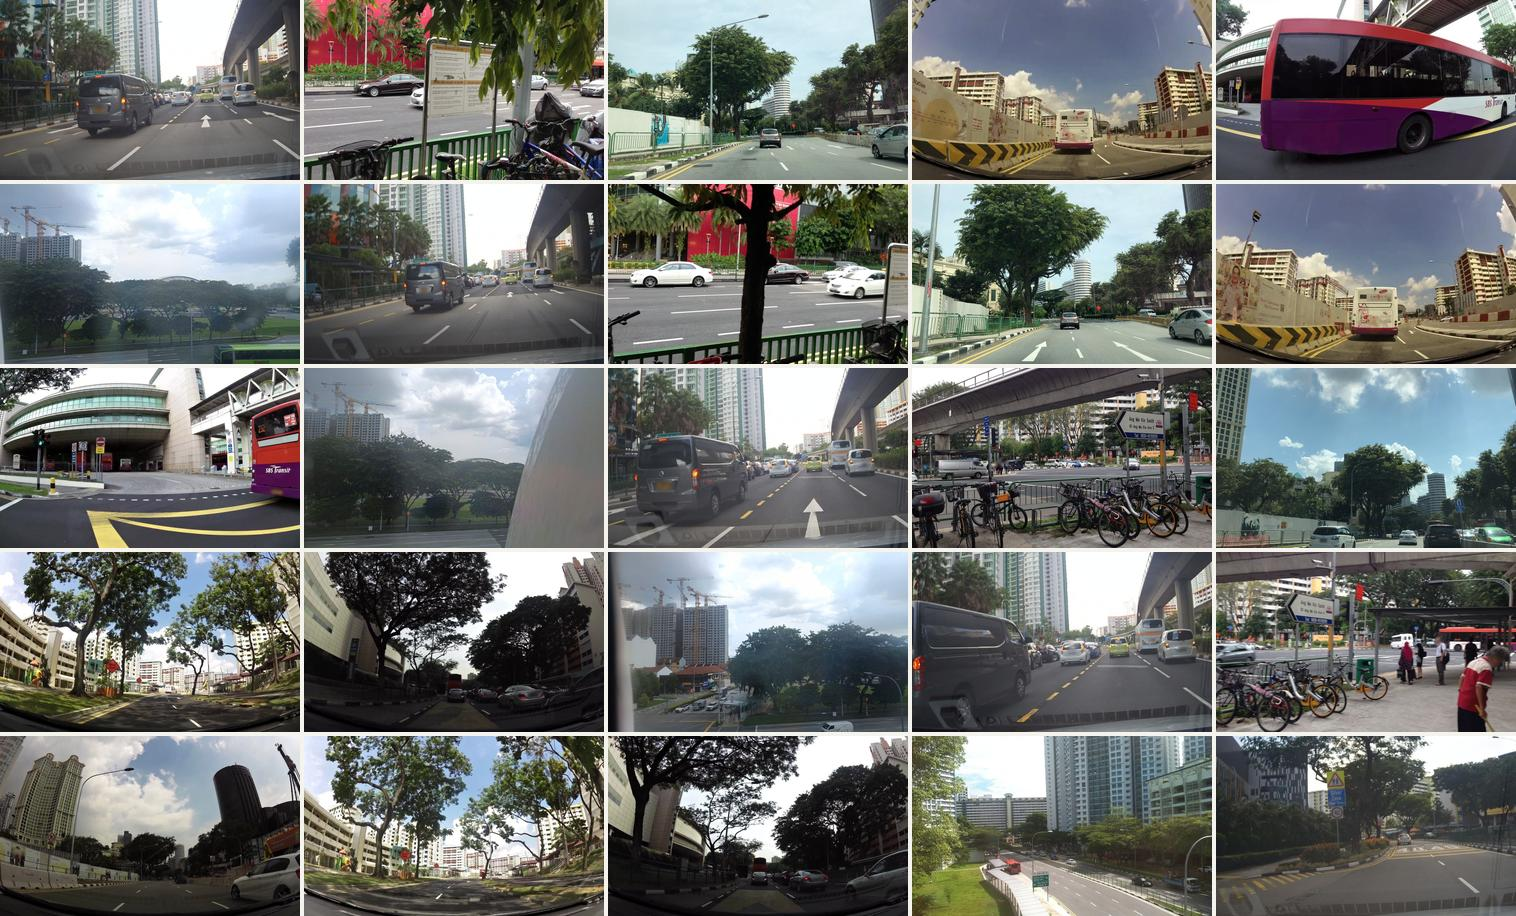


SEGMENTATION GRID


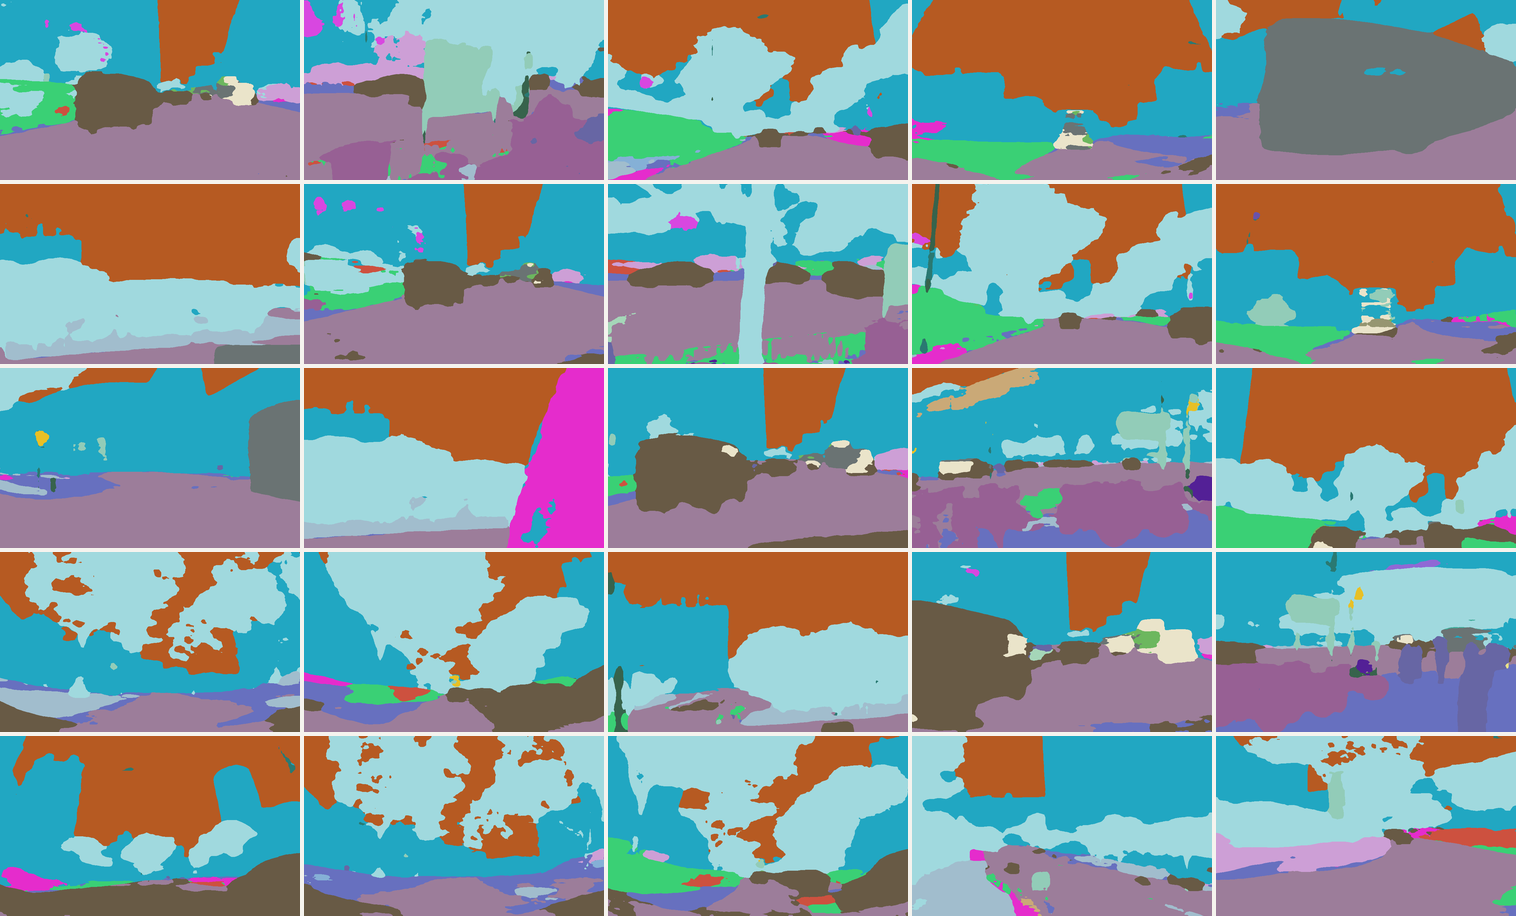

In [24]:
# ============================================================
# SAFE FRONTEND PREVIEW
# ============================================================

PREVIEW_SEED = (
    "CLEMENTI MRT"
)


PREVIEW_SIMILAR_COUNT = 5


preview_key = (

    f"{normalize_station(PREVIEW_SEED)}"

    "|"

    f"{PREVIEW_SIMILAR_COUNT}"

)


print(
    "Preview key:",
    preview_key
)


preview_query = (
    QUERY_LOOKUP.get(
        preview_key
    )
)


if not preview_query:

    print()
    print(
        "❌ THIS QUERY WAS NOT SUCCESSFULLY BUILT."
    )

    print(
        "Check the query-generation output above."
    )


else:

    print()

    print(
        "MRTs:"
    )


    for station in preview_query[
        "stations"
    ]:

        count = (

            library_by_station

            .get(
                station,
                {}
            )

            .get(
                "imageCount",
                0
            )

        )


        print(
            " ",
            station,
            "→",
            count,
            "library images"
        )


    print()

    print(
        "Selected grid images:",
        preview_query[
            "imageCount"
        ]
    )


    original_path = (

        PROJECT_DIR

        /

        preview_query[
            "originalGrid"
        ].removeprefix(
            "./"
        )

    )


    segmentation_path = (

        PROJECT_DIR

        /

        preview_query[
            "segmentationGrid"
        ].removeprefix(
            "./"
        )

    )


    print()

    print(
        "Original exists:",
        original_path.exists()
    )

    print(
        original_path
    )


    print()

    print(
        "Segmentation exists:",
        segmentation_path.exists()
    )

    print(
        segmentation_path
    )


    if (
        original_path.exists()
        and
        segmentation_path.exists()
    ):

        original_preview = (
            Image.open(
                original_path
            )
        )


        segmentation_preview = (
            Image.open(
                segmentation_path
            )
        )


        print()
        print(
            "ORIGINAL GRID"
        )


        display(
            original_preview
        )


        print()
        print(
            "SEGMENTATION GRID"
        )


        display(
            segmentation_preview
        )

In [25]:
# ============================================================
# DIAGNOSE WHY EACH MRT HAS / HAS NOT GOT IMAGERY
# ============================================================

diagnostic_rows = []


for station in ALL_MRT_STATIONS:

    observations = [

        observation

        for observation
        in clean_observations

        if observation["station"] == station

    ]


    mapillary_ids = {

        observation["mapillaryId"]

        for observation
        in observations

    }


    jpg_count = sum(

        1

        for image_id
        in mapillary_ids

        if original_image_path(
            image_id
        ).exists()

    )


    segmentation_count = sum(

        1

        for image_id
        in mapillary_ids

        if segmentation_path(
            image_id
        ).exists()

    )


    usable_count = (

        library_by_station

        .get(
            station,
            {}
        )

        .get(
            "imageCount",
            0
        )

    )


    diagnostic_rows.append({

        "station":
            station,

        "stored_observations":
            len(
                observations
            ),

        "unique_mapillary_ids":
            len(
                mapillary_ids
            ),

        "downloaded_jpgs":
            jpg_count,

        "segmentation_masks":
            segmentation_count,

        "usable_images":
            usable_count

    })


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


display(
    diagnostic_df
)


print()
print("MRTs with NO stored Mapillary observations:")


display(

    diagnostic_df[

        diagnostic_df[
            "stored_observations"
        ]
        ==
        0

    ]

)

TypeError: 'WindowsPath' object is not callable